In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv(' https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv')

In [ ]:
df

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...,...
392,393,Prof,A,33,30,Male,103106
393,394,Prof,A,31,19,Male,150564
394,395,Prof,A,42,25,Male,101738
395,396,Prof,A,25,15,Male,95329


In [ ]:
df.columns

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [ ]:
#rename unnamed column to unique key
df.rename (columns={"Unnamed: 0": "Unique Key"}, inplace=True)

In [ ]:
df.isnull()

,Unique Key,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
392,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False


In [ ]:
#finding the number of missing values in each row.
df.isnull().sum()

,0
Unique Key,0
rank,0
discipline,0
yrs.since.phd,0
yrs.service,0
sex,0
salary,0


In [ ]:
#finding the total numbe rof missing values
#there is no missing value in the dataset
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#data exploration
df.describe()

,Unique Key,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


In [ ]:
df.groupby(['sex'])['Unique Key'].count()

,Unique Key
sex,
Female,39
Male,358


<Axes: xlabel='sex', ylabel='count'>

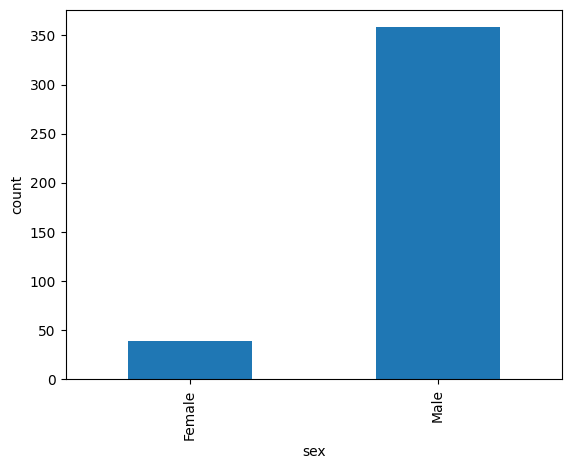

In [ ]:
#nearly 10 more men than women
df.groupby(['sex'])['Unique Key'].count().plot(kind='bar', xlabel = 'sex', ylabel = 'count')

Based on the above information

General information:
This dataframe represents 397 professors, associate professors and assistant professors (39 females and 358 males) with an average of 22 years post doc, who have worked an average of 17 years and make $113,706 on average.

Compare average salaries of male vs female professors/assistant professors.

In [ ]:
#finding average salary based on gender
#Men on average make more than women, there is also nearly 10X more men than women in the dataset.
df.groupby(['sex'])['salary'].mean()

,salary
sex,
Female,101002.410256
Male,115090.418994


<Axes: ylabel='salary'>

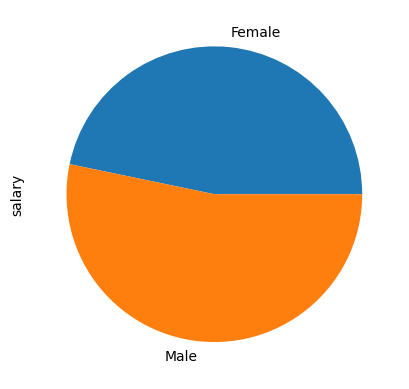

In [ ]:
#pie chart showing salary favoring the male
df.groupby(['sex'])['salary'].mean().plot(kind="pie")

In [ ]:
#comparing the salaries at different ranks based on sex
df.groupby(['sex', 'rank'])['salary'].mean()

sex     rank     
Female  AssocProf     88512.800000
        AsstProf      78049.909091
        Prof         121967.611111
Male    AssocProf     94869.703704
        AsstProf      81311.464286
        Prof         127120.822581
Name: salary, dtype: float64

^^ Men make more salary than female at every rank

In [ ]:
#Create a new table for female data only
#i couldn't figure out how to do it all at once so i did the columns (df2) then females only (df3)

df2 = df[['Unique Key','rank','sex','salary']]

In [ ]:
df2

,Unique Key,rank,sex,salary
0,1,Prof,Male,139750
1,2,Prof,Male,173200
2,3,AsstProf,Male,79750
3,4,Prof,Male,115000
4,5,Prof,Male,141500
...,...,...,...,...
392,393,Prof,Male,103106
393,394,Prof,Male,150564
394,395,Prof,Male,101738
395,396,Prof,Male,95329


In [ ]:
df3 = df2[df2['sex'] == 'Female']

In [ ]:
df3

,Unique Key,rank,sex,salary
9,10,Prof,Female,129000
19,20,Prof,Female,137000
24,25,AssocProf,Female,74830
34,35,AsstProf,Female,80225
35,36,AsstProf,Female,77000
47,48,Prof,Female,151768
48,49,Prof,Female,140096
52,53,AsstProf,Female,74692
63,64,AssocProf,Female,103613
68,69,Prof,Female,111512


In [ ]:
Top 5 highest female salary
df3.sort_values(by='salary', ascending=False).head()

,Unique Key,rank,sex,salary
323,324,Prof,Female,161101
47,48,Prof,Female,151768
148,149,Prof,Female,144651
48,49,Prof,Female,140096
19,20,Prof,Female,137000


In [ ]:
#comparing the highest female salary with males above her (she is #7)
df[df['salary'] > 161000].sort_values(by = 'yrs.service', ascending = True).head(7)


,Unique Key,rank,discipline,yrs.since.phd,yrs.service,sex,salary
204,205,Prof,B,19,5,Male,165000
249,250,Prof,A,29,7,Male,204000
290,291,Prof,A,33,7,Male,174500
190,191,Prof,B,22,9,Male,180000
292,293,Prof,A,39,9,Male,183800
302,303,Prof,A,28,13,Male,170500
323,324,Prof,B,24,15,Female,161101


Based on the analysis done we see that there are more men than women, nearly 10 times more, and they take home a higher salary at every rank.

I find it interesting that there are 6 men who make more that the top women and they all have less years of service & a wider gap between years since phd and years of service.

Those men may have pursued opportunities that allowed them to join the service later with more experience and negoitate a better salary.

Notable -- A male professor in the same discipline, less years after PHD and and 1/3 of the time that she has been in service and he already makes $5000 more than her.